# Journal de bord - [Orientation et tri multimodal des demandeurs d'emploi par l'Intelligence Artificielle]
---

## 📅 Journal de bord – Semaine 0 (06/09/2026)

### 🔧 Étapes / Actions réalisées
- Découverte du sujet
- Récupération des ressources
- Initialisation de l'environnement de travail
   + initialisation du repo GIT > clone local
   + création environnement virtuel Python
   + structuration des dossiers
- Premier découpage des taches > planification

### 📝 Observations / Difficultés
- Sujet d'Examen : Orientation et tri multimodal des demandeurs d'emploi par l'Intelligence Artificielle
- Client : Agence nationale pour l'emploi
- Problématique IA : tâche de classification supervisée multiclasse (3 classes)
- Jeu de données : fichier csv (`dataset_trajectoire_emploi_Sujet Examen CISIA - Promo Upskilling Atlas - mai-oct2026 (Session-00279143).csv`)
   + Donneés tabulaires, textuelles, variable cible
- Plannifier le travail des prochaines semaines
- anticipation sur le cadrage métier et compréhension de la problématique IA

### 🎯 Prochaines étapes
- Planification

| Semaine	| Période	    | Objectif principal
|---|---|---|
| Semaine 0	| 05/09 → 06/09	| Cadrage + Mise en place place environnement
| Semaine 1	| 07/09 → 13/09	| Compréhension des données + EDA
| Semaine 2	| 14/09 → 20/09	| Préparation des données + premiers modèles
| Semaine 3	| 21/09 → 27/09	| Comparaison des scénarios + choix du modèle
| Semaine 4	| 28/09 → 04/10	| Industrialisation + rédaction finale + slides
| Semaine 5	| 05/10 matin	| Relecture finale et dépôt

---

## 📅 Journal de bord – Semaine 1 (07/09/2026)

### 🔧 Étapes / Actions réalisées

- Découverte/compréhension des données du dataset `dataset_trajectoire_emploi_Sujet Examen CISIA - Promo Upskilling Atlas - mai-oct2026 (Session-00279143).csv`
- EDA :
   + qualification des données (variables qualitatives/quantitatives/target)
   + qualité des données
   + distribution des variables
   + relation et corrélation entre variables => tester chaque variable ?
- Rédaction de la synthèse EDA

### 📝 Observations / Difficultés
- choisir les bons graphiques, ne pas surdétailler l'analyse
- plusieurs relectures nécessaires

### 🎯 Prochaines étapes
- Préparation des données
      + feature enginering
      + split train/test
- Mise en place des scénarios
- 

## 📅 Journal de bord – Semaine 1 (11/09/2026)

### 🔧 Étapes / Actions réalisées

- Finalisation EDA
- Préparation des données
   + feature enginering : classification des variables pour la préparation du pipeline
   + Découpage train/test stratifié, AVANT toute transformation
   + Construction du pre-processing
   + préparaption des scénarios de données

### 📝 Observations / Difficultés

- etape importante pour la suite : on commence à travailler le jeu de données (split train/test) et on définit les premiers traitements qui seront réalisés dans le pipe d'entrainement.
- Attention : bien isoler le jeu de test pour éviter les fuites
- Catégoriser les variables pour effectuer le bon traitement dans le pipe (se baser sur l'EDA)
- Définir les traitements appropriés pour chaque variable (notemment, l'imputation des valeurs nulles)
   + développement d'une précure de pre-processing
-  Réflechir au séquencement de l'entrainement :
   + Définition et préparation des 4 scénarios : sélection des features
   + Pour chaque scénario,  on entrainera 3/4 modèles différents (à sélectioner plus tard)
   + en d'autre terme : on boucle sur les scénarios et pour chaque scenario, on boucle sur les modèles
   + important : bien s'assurer que le même traitement soit effectué sur les données d'entrainement afin d'obtenir des résultats comparables (et reproductibles)
- 

### 🎯 Prochaines étapes

- sélectionner les modèles candidats
- sélectionner les métriques de performance
- Pour chaque scénario et chaque modèle : lancer l'entrainement et effectuer les tests de validation

## 📅 Journal de bord – Semaine 2 (14,15/09/2026)

### 🔧 Étapes / Actions réalisées

- Les scenarios sont définis S1,2,3,4
- Sélection des modèles candidats : LogReg, RandomForest, LightGBM, XGBoost
- sélections de métriques en rapport avec l'enjeu métier  : Acuracy, F1 score, Matrice de confusion
- Développement du pipeline d'entrainement (validation croisée)
     + boucle sur 4 scenarios et 4 modèles
- exécution et déboggage du code
     + affichage des résultats de la validation croisée
- comparaison des modèles et choix du meilleur modèle
- optimisation des paramètres sur le meilleur modèle : XGBoost
- Réentrainement du meilleur modèle (validation croisée) avec les paramètres sélectionnés
- Evaluation finale sur jeu de test
   + affichage des métriques : Balance Accracy ,F1-macro, Recall Classe 2, Matrice de confusion



### 📝 Observations / Difficultés

- choix de 4 modèles parmi la liste :

| Modèle | Famille | Pourquoi candidat ? | Coût (entraînement / inférence) | Explicabilité |
|---|---|---|---|---|
| Régression Logistique | Linéaire | Baseline incontournable, très rapide, coefficients interprétables, fonctionne bien avec TF-IDF | faible / faible | élevée |
| Naive Bayes Multinomial | Probabiliste | Très efficace sur les variables textuelles vectorisées (TF-IDF), excellent point de comparaison NLP | très faible / très faible | élevée |
| Arbre de Décision | Arbre | Modèle simple à visualiser et expliquer aux métiers, fournit une référence explicable | faible / faible | très élevée |
| Random Forest | Ensemble (bagging) | Robuste au bruit et aux valeurs atypiques, peu sensible au sur-apprentissage, peu de réglages nécessaires | moyen / faible | moyenne |
| Extra Trees (ExtraTreesClassifier) | Ensemble (bagging) | Variante souvent plus performante que Random Forest sur données tabulaires hétérogènes | moyen / faible | moyenne |
| Gradient Boosting | Ensemble (boosting) | Référence classique pour les données tabulaires, capture les relations non linéaires | élevé / faible | moyenne |
| XGBoost | Ensemble (boosting) | Benchmark industriel sur données tabulaires, souvent parmi les meilleurs compromis performance/coût | élevé / faible | moyenne |
| LightGBM | Ensemble (boosting) | Très performant et rapide sur données tabulaires, entraînement plus efficace que XGBoost sur certains jeux de données | moyen à élevé / faible | moyenne |
| CatBoost | Ensemble (boosting) | Excellente gestion des variables catégorielles, souvent très performant avec peu de prétraitement | moyen / faible | moyenne |
| SVM (LinearSVC ou SVC) | Marges maximales | Souvent performant sur jeux de données de taille modérée avec représentation TF-IDF | moyen à élevé / faible | faible à moyenne |



   + je garde les 3 modèles proposés dans l'enoncé
   + je rajoute LogisticRegression qui constitue souvent une baseline (modèle simple et rapide)

- sélection des métriques :
    + Objectif : comparer perf et stabilité et coût, à performance comparable, on prend le plus simple
    + Accuracy : c'est la base, mais ne sera pas utilisé pour la perf
    + F1 :Le F1-score est la métrique de choix sur classes déséquilibrées. choisir F1-macro/F1-weighted
        * Chaque classe représente un enjeu métier + Déséquilibre de classes.
        * ➡️ Le `F1-macro` donne le même poids aux classes majoritaires et minoritaires.
    + vu l'enjeu métier sur la classe 2, je pourrais rajouter le recall sur cette classe ?
        * ne peut pas être calculé directement avec les scoreurs standard de cross_validate(), car il faut cibler une classe particulière. la validation croisée sert à sélectionner le candidat, puis le Recall de la classe 2 et la Matrice de confusion servent à vérifier que le modèle retenu respecte bien l'enjeu métier critique (ne pas manquer les cas de risque élevé).

Développement et éxécution du pipeline d'entrainement : 
   + Développement de la boucle : 4 scenarios, 4 modèoes, soit un tableau de résultat à 16 lignes (1 ligne par entrainement)
   + Pour la première éxécution, je ocnsidère une configuration standrad des 4 modèles
   + 1ère éxécution du pipe pour test et debug => problème technique avec xgboost : compatibilité XGboost python 3.14

    ```
    pip show xgboost
    Name: xgboost
    Version: 3.4.1
    Summary: XGBoost Python Package
    Home-page:
    Author:
    Author-email: Hyunsu Cho <chohyu01@cs.washington.edu>, Jiaming Yuan <jm.yuan@outlook.com>
    License-Expression: Apache-2.0
    Location: /home/a453784/simplon-briefs/Atlas_CISIA_Exam/.venv/lib/python3.14/site-packages
    Requires: numpy, nvidia-nccl-cu13, scipy
    Required-by:
    
    pip uninstall xgboost
    Found existing installation: xgboost 3.4.1
    
    pip install xgboost==2.1.4
    
    ```

- Analyse des résultats :

| #  | Modèle              | F1-macro          | Accuracy | Pred (s) | Train (s) |
|----|---------------------|-------------------|----------|----------|-----------|
| S1 | LogisticRegression  | 0.673 ± 0.011     | 0.687    | 0.0232   | 0.21      |
| S1 | RandomForest        | 0.673 ± 0.017     | 0.692    | 0.1806   | 1.53      |
| S1 | LightGBM            | 0.700 ± 0.022     | 0.715    | 0.0309   | 18.69     |
| S1 | XGBoost             | 0.695 ± 0.015     | 0.718    | 0.0284   | 1.59      |
| S2 | LogisticRegression  | 0.645 ± 0.012     | 0.663    | 0.0223   | 0.06      |
| S2 | RandomForest        | 0.636 ± 0.019     | 0.657    | 0.1797   | 1.52      |
| S2 | LightGBM            | 0.626 ± 0.023     | 0.645    | 0.0314   | 21.11     |
| S2 | XGBoost             | 0.617 ± 0.024     | 0.650    | 0.0325   | 0.33      |
| S3 | LogisticRegression  | 0.635 ± 0.017     | 0.651    | 0.0147   | 0.05      |
| S3 | RandomForest        | 0.635 ± 0.017     | 0.651    | 0.1753   | 1.30      |
| S3 | LightGBM            | 0.635 ± 0.017     | 0.651    | 0.0215   | 4.55      |
| S3 | XGBoost             | 0.635 ± 0.017     | 0.651    | 0.0217   | 0.11      |
| S4 | LogisticRegression  | 0.544 ± 0.021     | 0.557    | 0.0166   | 0.08      |
| S4 | RandomForest        | 0.680 ± 0.012     | 0.700    | 0.1768   | 1.45      |
| S4 | LightGBM            | 0.648 ± 0.027     | 0.661    | 0.0285   | 15.54     |
| S4 | XGBoost             | 0.647 ± 0.022     | 0.673    | 0.0239   | 0.29      |

   + Globalement, le S1 (sélection de toutes les données) donne de meilleurs résultats
   + Sur S1, XGboost meilleur
   + je sélectionne XGBoost, optimise les hyperparamètres, réentraine et valide sur le test pour voir
      * pour ce premier run, je limite volontairement à 2 à 3 jeux d'hyperparamètres
      * J'utiliserai GridSearchCV / RandomizedSearchCV pour aller plus loin si nécessaire

- Evaluation finale du meilleur modèle sur le test (avec les meilleurs hyperparamètres sélectionnés)

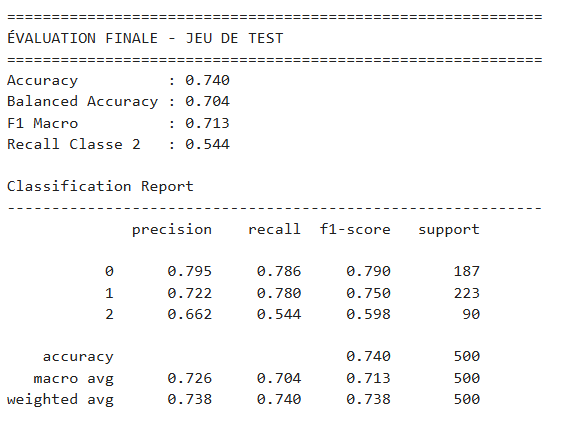

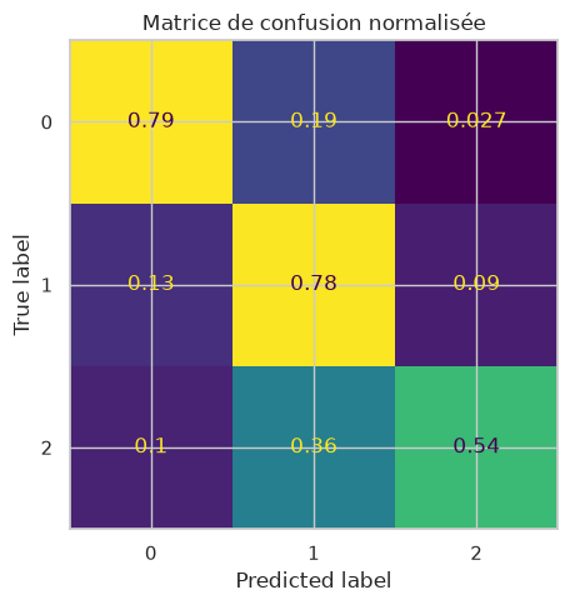

   + le `F1-macro` est conforme aux attentes : `0.713`
   + le Recall Classe 2 est décevant : `0.544`
   + le rapport de classification montre de bons résultats sur les classes 0 et 1, mais est très decevant sur la classe 2 : Le modèle ne détecte qu'environ 1 cas sur 2 appartenant réellement à la classe 2, ce qui me semble trop faible par rapports aux enjeux métiers de cette classe (détection chomage longue durée)
   + la matrice montre que la classe 1 est souvent confondue avec la classe 2 => 0,36

2 possibilités

- optimiser XGboost (pondération des classes, SMOTE, réoptimisation des hyperparamètres, ajustement du seuil de décision)
- reboucler sur 5.2 pour voir si je ne passe pas à coté d'un modèle qui offrirait un meilleur compromis F1-macro/recall classe 2




### 🎯 Prochaines étapes

- reboucler sur 5.2
- sélectionner les 2-3 meilleurs modèles
- optimisation des hyperparamètres (?)
- Pour chaque scénario et chaque modèle : pousser jusqu'à évaluation finale sur jeu de test

## 📅 Journal de bord – Semaine 2 (19,20,21/09/2026)

### 🔧 Étapes / Actions réalisées

- Reboucler sur 5.2 et afficher le recall classe 2 lors de la cv
- sélectionner le meilleur modèle selon la performance (f1-macro), le métier (recall classe 2), l'aspect technique (tps d'inference et d'entrainement), 
- optimiser les hyperparamètres du meilleurs modèle
- lancer le test de validation final (sur jeu de test)
- synthèse de modélisation
- Analyse des scénarios

Pipeline de travail : 

```
Entrainement
│
├─ Benchmark CV - 16 runs
│   └─ 4 scénarios × 4 modèles
│
├─ Sélection des meilleurs candidats
│   └─ Métriques : F1 macro, Recall Classes 2, train(s), predict(s)

Optimisation meilleur modèle
│
├─ hyperparamètres
├─ poids des classes
├─ seuil de décision

Évaluation finale sur Test
│
├─ Experiment sur meilleur candidat - 1 run
│   ├─ métriques métier : F1 macro, Recall classe 2, balanced accuracy (metrique secondaire)
│   ├─ Artefacts : matrice de confusion, rapport de classification
│   └─ 


```




### 📝 Observations / Difficultés

- Mon erreur sur la première passe : ne pas avoir considéré le recall Classe 2
- 2ème passe, le meilleur modèle est Regression Logistic
- reprise de l'optimisation des hyperparamètres sur Logistic Regression
   + 4 jeux d'hyperparamètres : Baseline, régul forte, faible et elasticNet
- Sélection du meilleur jeu d'hyperparamètres
- Evaluation finale sur jeu de test
   + Résutat F1 macro conforme à la validation croisée
   + Résultat Recall Classe 2 légèrement décevant : 0,644 mais meilleur qu'avec XGBoost
   + Possible optimisation :  ajustement des seuils de décision, pondération sépcifique des classes, recherche d'hyperparamètres plus large
   + Je choisi de rester sur ces pramètres sans optimisation supplémentaire : Je crains manquer de temps et je ne suis pas sûr que le ratio gain de recall / temps de bouclage en vaille la peine. Je peux toujours revenir dessus après la phase d'indus.

- le code du notebook se répète : sélection du modèle (cv), sélection des hyperparamètres (cv), test final
     + factorisation du code et création des fonctions : `benchmark.py`, `train_model.py` et `evaluation.py`
 
- Concernant l'analyse des sénarios, je me base sur les réultats de logistic regression en §5.2 : entrainement et vaidation croisée.
     + le tableau 5.2 dispose de toutes les métriques pour comparer

- Analyse éthique :
     + vérifier les textes RGPD / Loi numérique quant à l'utilisation des variables sensibles (nationalite_hors_ue et age) dans les modèles IA
     + quelles sont les mesures de contrôle des biais et de transparence => explicabilité, décision finale humaine 
 
- 

### 🎯 Prochaines étapes

- Industrialisation : tracking MLflow, API, Streamlit

## 📅 Journal de bord – Semaine 3 (23,24,25/09/2026)

### 🔧 Étapes / Actions réalisées

- Persistence du modèle et tracking MLflow
- Développement de l'API => `/health`, `/model-info`, `/predict`, `/retrain`
- Développement de l'interface streamlit
- Les tests unitaires sont effectués en local (mlflow, api, streamlit)
- Une fois validé, je dockerise tout


### 📝 Observations / Difficultés

#### Persistence du modèle :
- Je persiste le modèle 2 fois :
   + en local (`joblib`) : pratique pour les tests
   + sur mlflow : pour la traçabilité

- Instanciation du serveur MLFlow (en local)
``` cmd
mlflow server \
    --host 127.0.0.1 \
    --port 5000 \
    --backend-store-uri sqlite:///app/mlflow/mlflow-data/mlflow.db \
    --artifacts-destination ./app/mlflow/artifacts

```

Architecture MLflow :
``` 
└── mlflow
    ├── artifacts
    └── mlflow-data
        └── mlflow.db
``` 

#### develepoment de l'api :

- Pour l'instant exécution de l'api en local : je teste et valide l'api en local, je dockerise à la fin.
- Architecture :
``` 
├── app
│   ├── api
│   │   ├── logs
│   │   │   └── predictions.jsonl            # traçabilité
│   │   ├── models
│   │   │   └── employment_risk_model.pkl    # Model sauvegardé (joblib)
│   │   ├── main.py                          # Script de l'api

``` 

- routes :
   + `/health` => ✅
   + `/model-info` => ✅
   + `/predict` => ✅
        * petit de problème de modèle/pipeline, mais résolu (il faut persister le pipeline et pas le modèle)
   + `/retrain` => compil ✅
        * 🟡 à tester : entrainement sur un nouveau jeu de données et vérifier la promotion (ou la non-promotion)

#### Test de l'api :

**Docs**

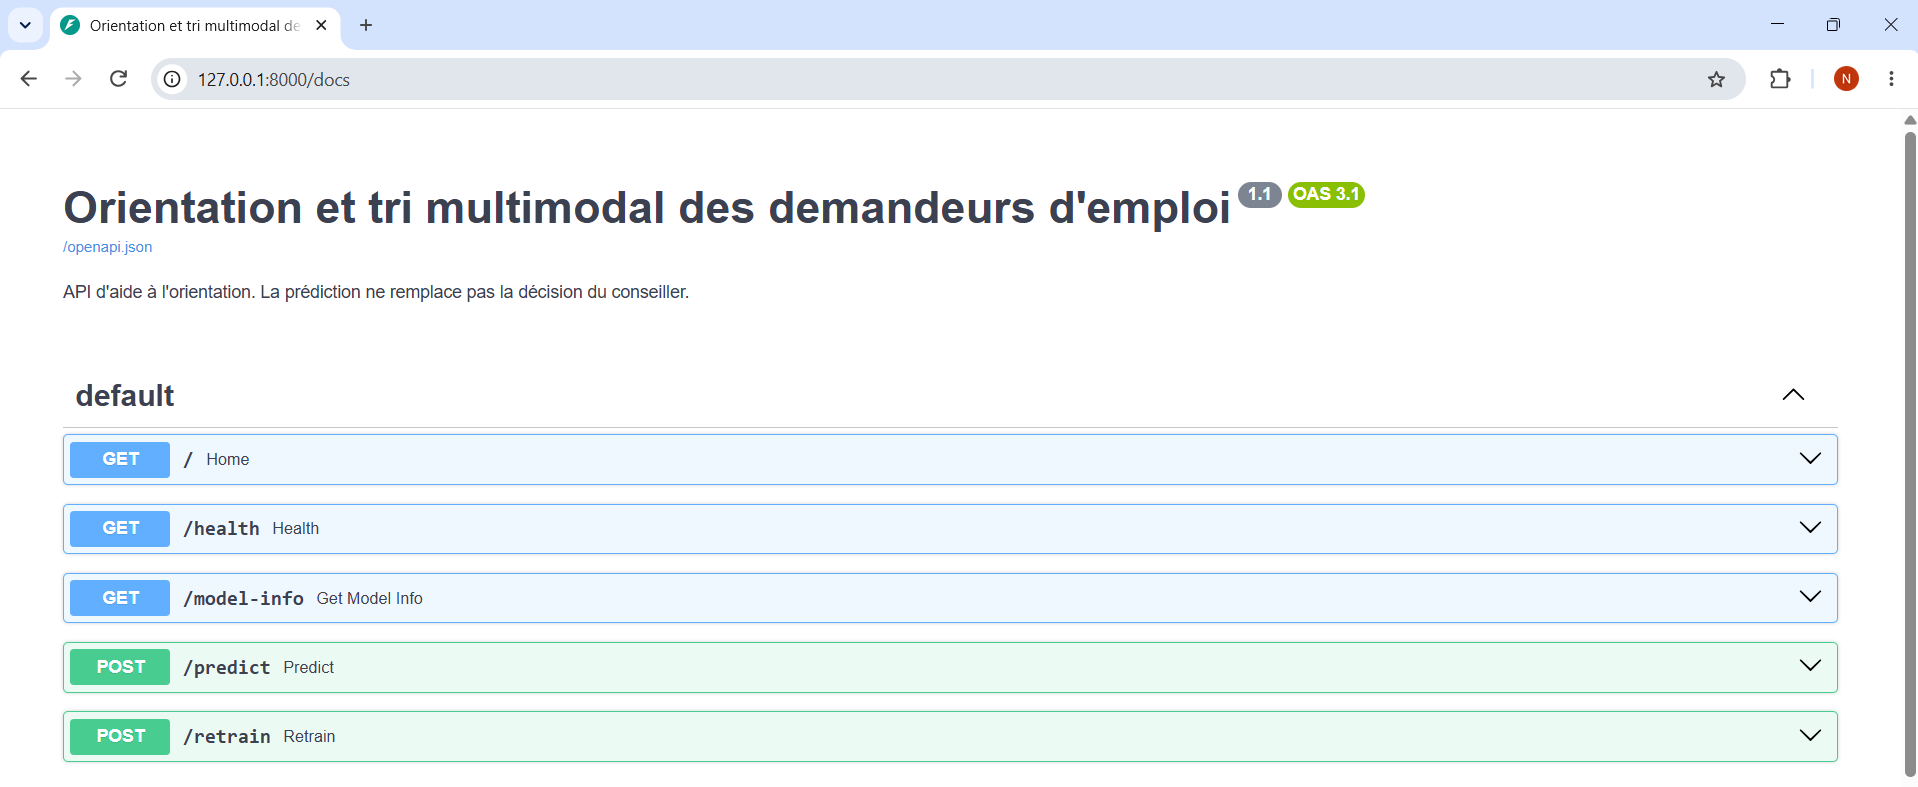

**Route /predict**

```
curl -X 'POST' \
  'http://127.0.0.1:8000/predict' \
  -H 'accept: */*' \
  -H 'Content-Type: application/json' \
  -d '{
  "usager_id": "ID_5050",
  "age": 22,
  "niveau_diplome": "Bac+2",
  "anciennete_poste_ans": 1,
  "code_rome_vise": "H1503",
  "code_insee_commune": "91240",
  "est_allocataire": 0,
  "nationalite_hors_ue": 0,
  "synthese_entretien": "Bonne présentation, compétences techniques à  jour. Reprise rapide visée."
}'
```

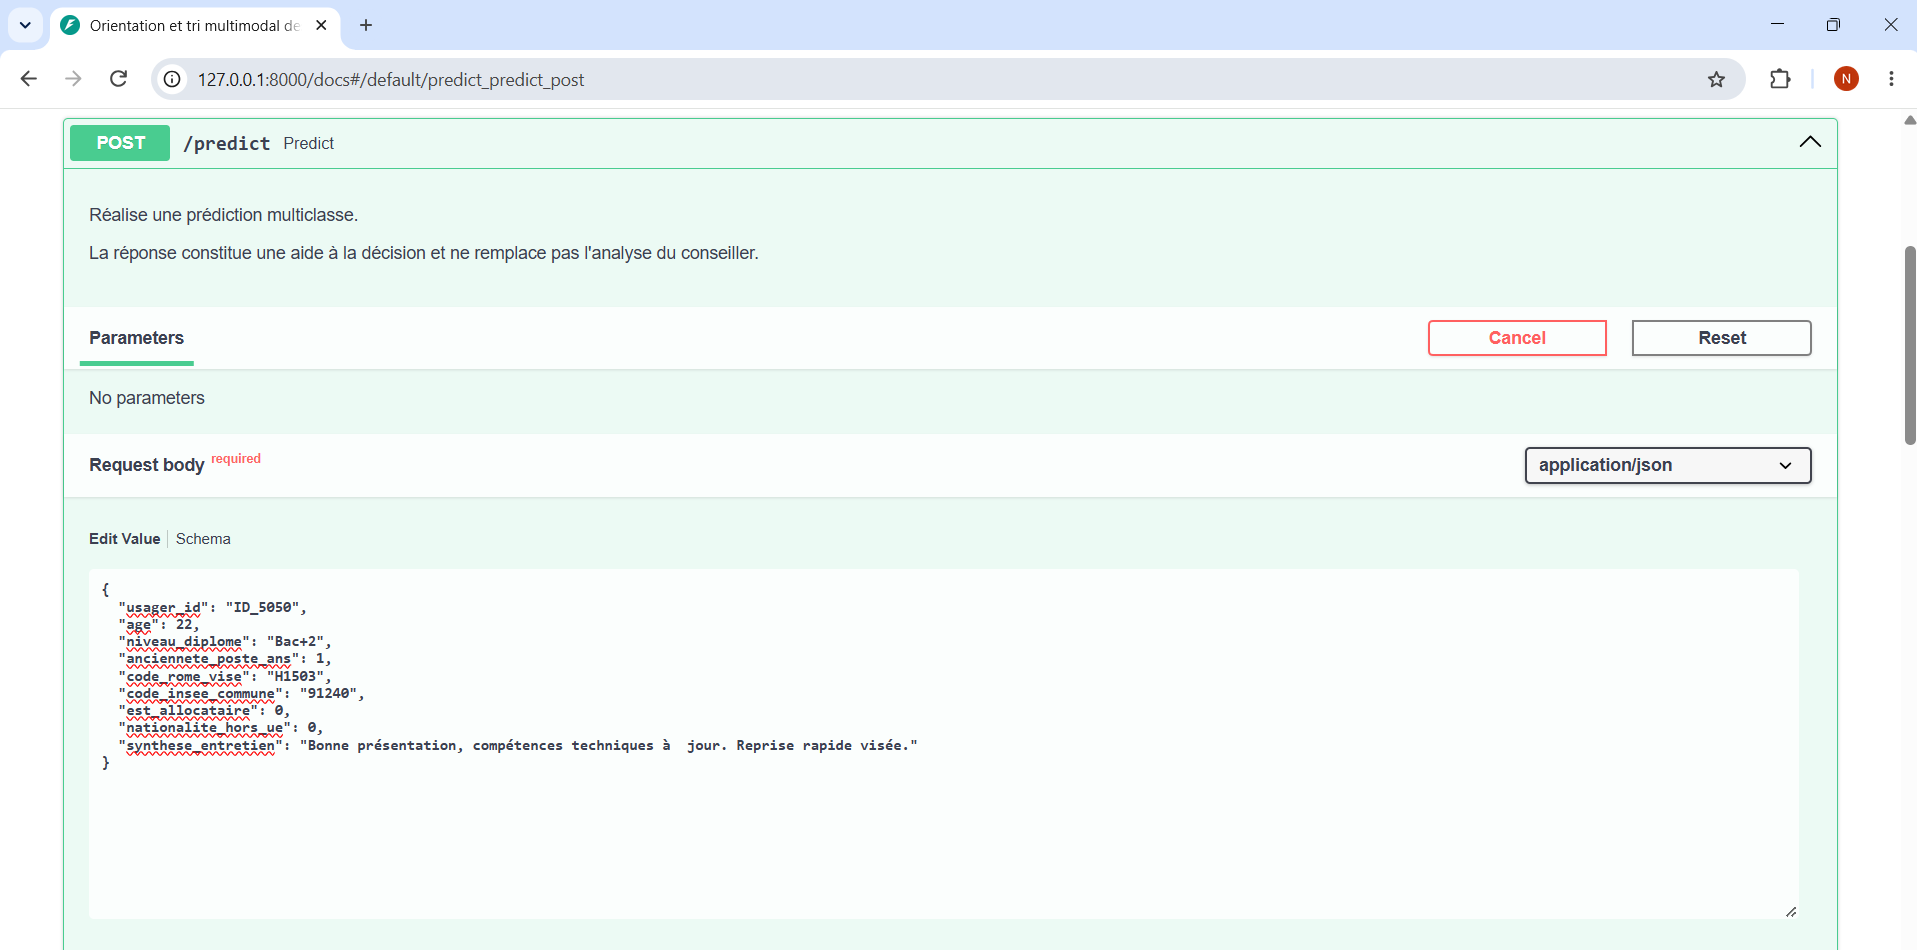



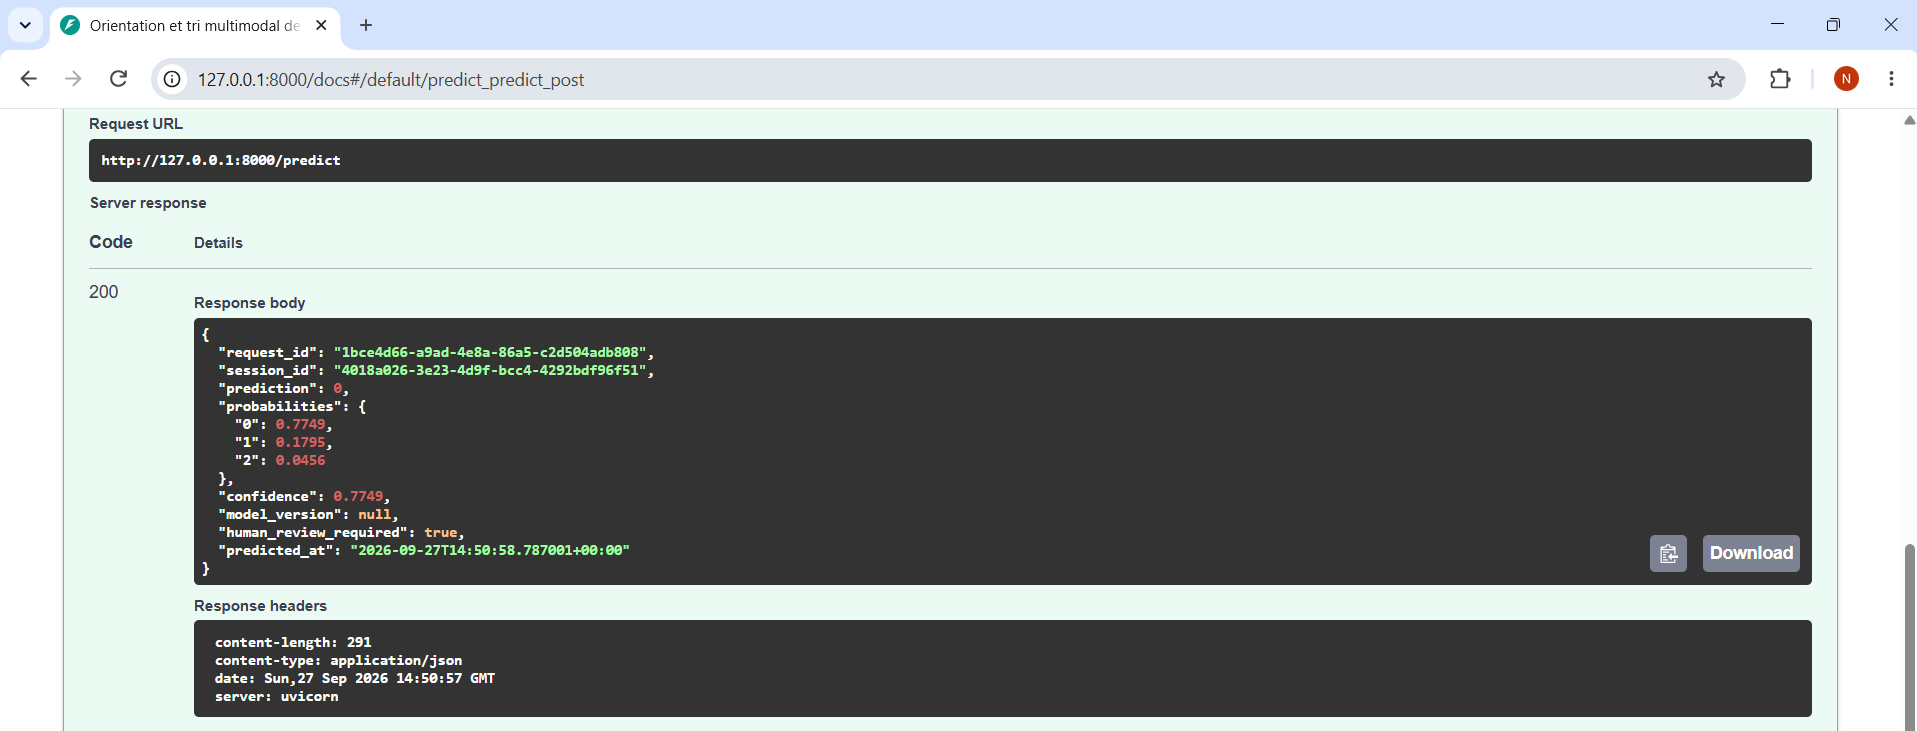


#### Logging de l'API
- refactoring du logger pour répondre aux éxigences du brief


#### End-point `/retrain`
- Ajout du end-point :
   1. Validation du dataset (CSV)
   2. Train / Validation Split
   3. Évaluation du champion actuel
   4. Réentraînement du candidat
   5. Calcul des métriques
   6. Vérification des garde-fous
   7. Enregistrement dans MLflow
   8. Promotion éventuelle via alias champion
   9. Rechargement du champion

- Test du end-point : test ok en local



#### develepoment Streamlit :

- Interface avec 2 onglets :
  + Prédiction : formulaire à renseigner et appel API /predict
  + Historique : consulter l'historique des prédictions

- Architecture
│   └── ui
│       ├── app.py                           # Script streamlit
│       ├── database
│       └── └── history.db                   # Base de données pour l'historique des requêtes API

- UI :
   + Formulaire prédiction
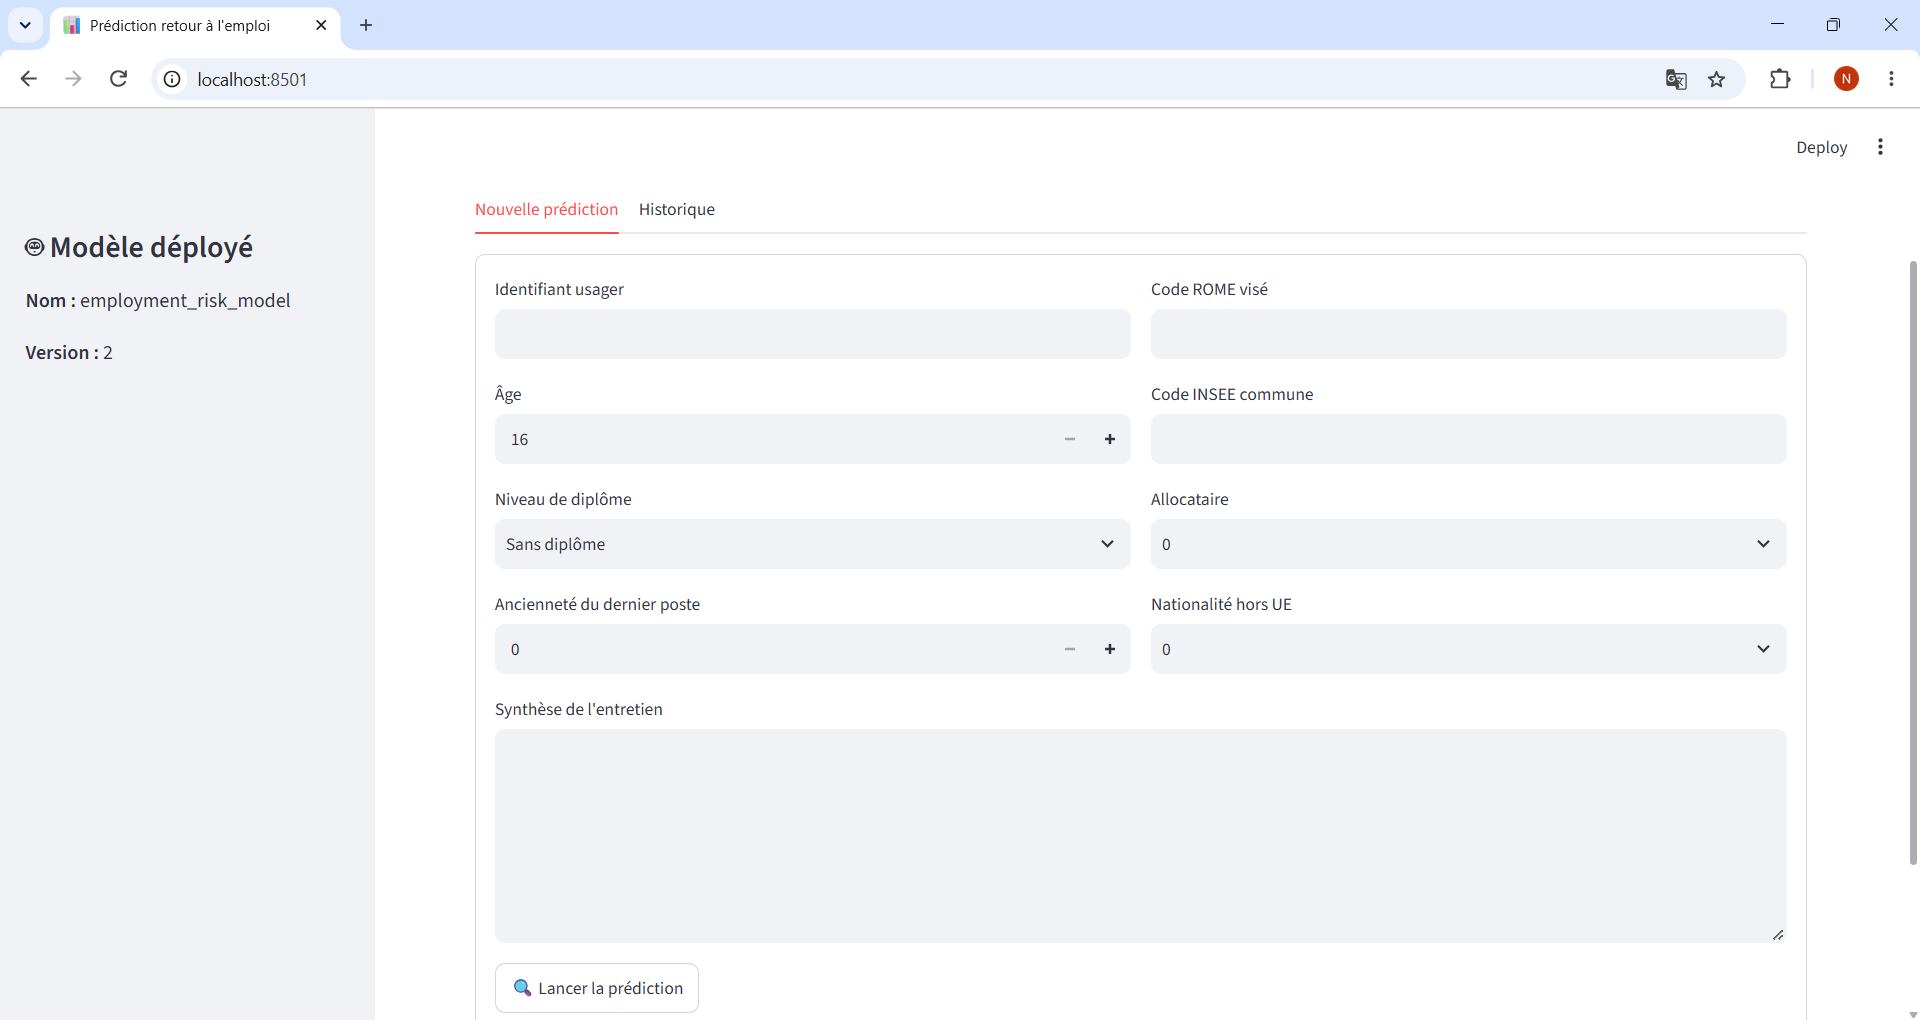
   + Résultat prédiction 
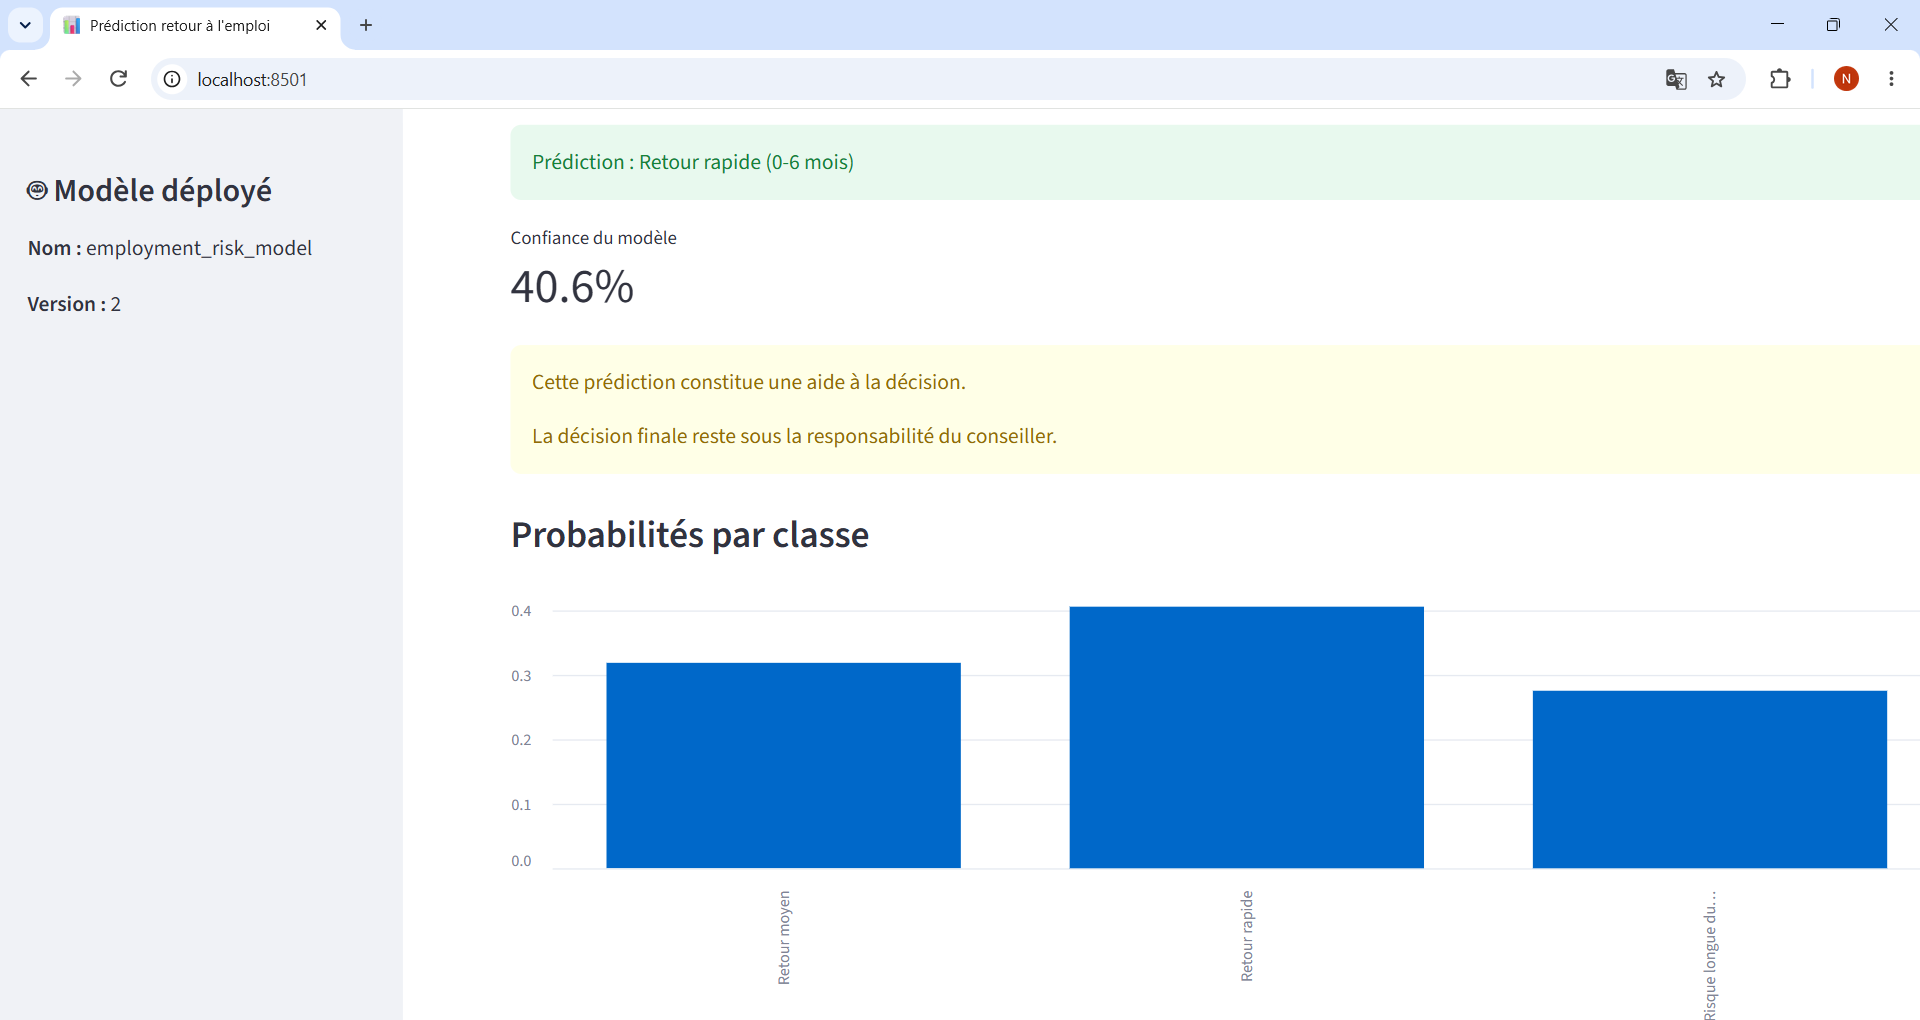

   + Historique
 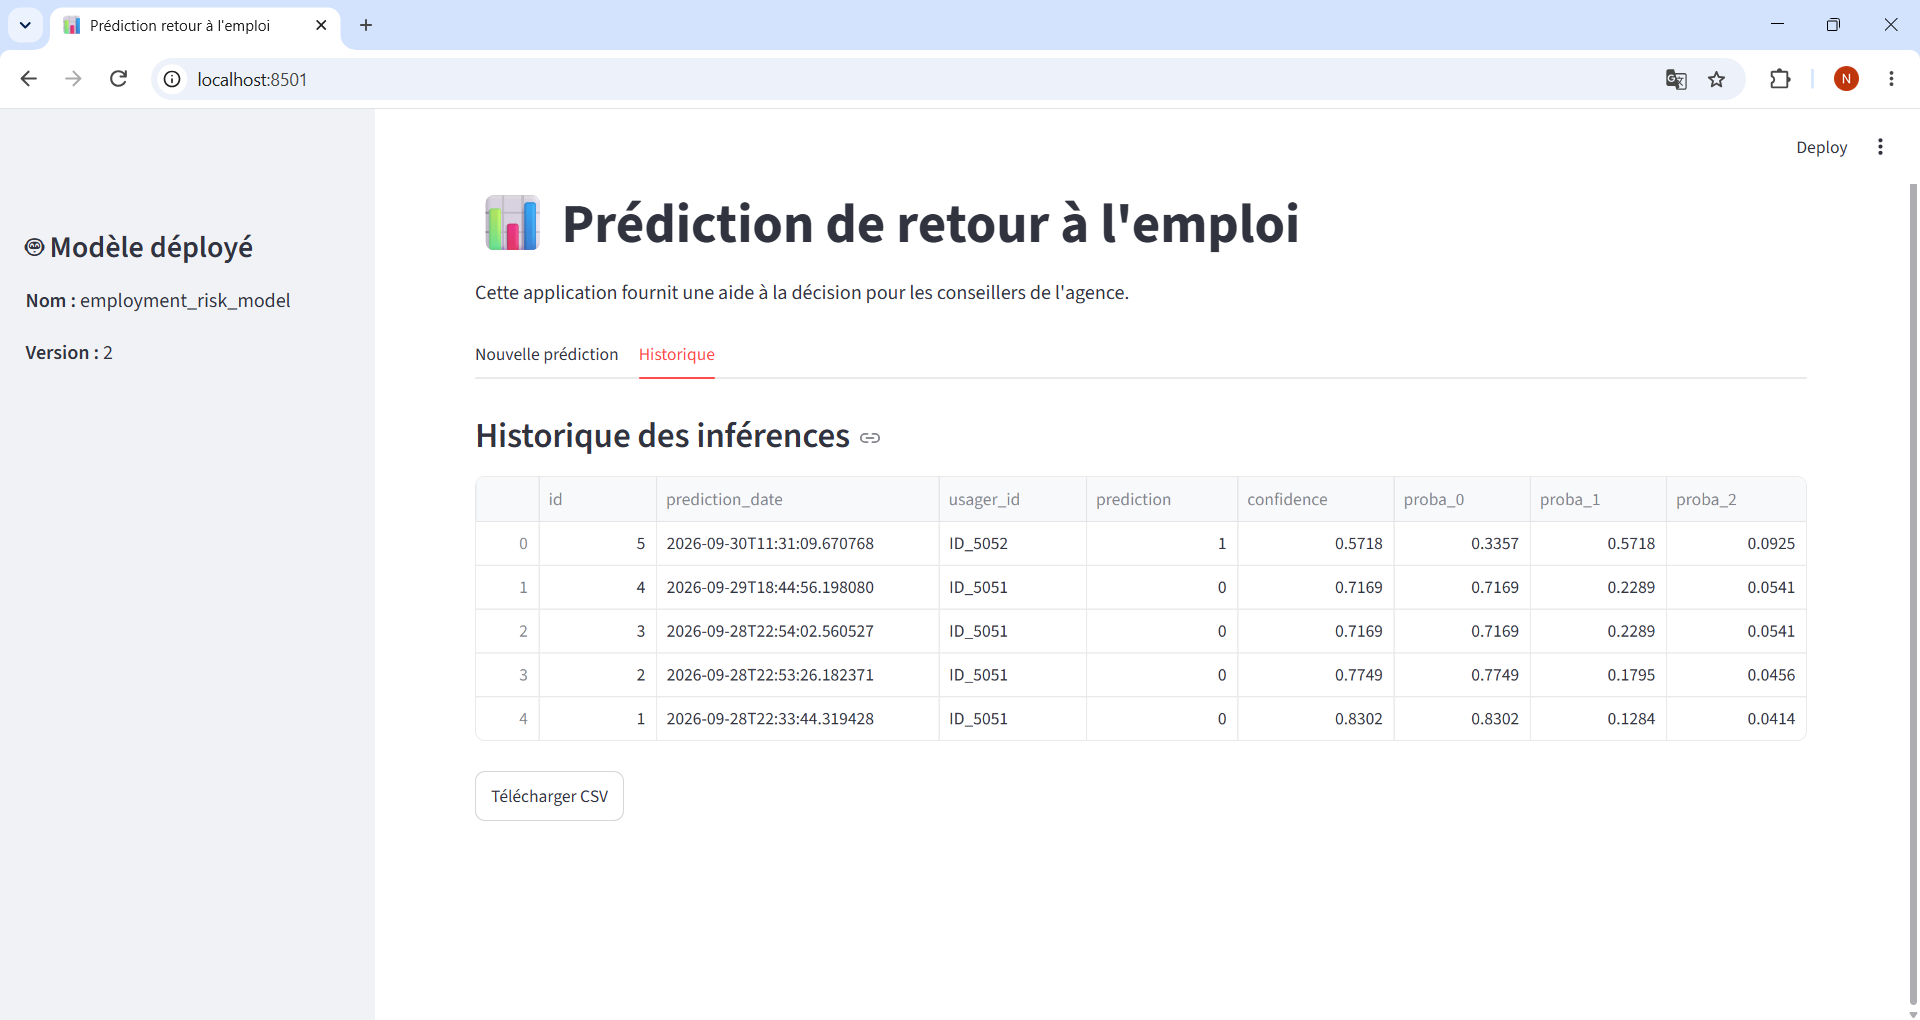
 





### 🎯 Prochaines étapes

- finaliser l'api : test complet du /retrain
- dockeriser
- mise en place de git-action
- monitoring

## 📅 Journal de bord – Semaine 4 (28-29-30/09/2026)

### 🔧 Étapes / Actions réalisées

- Integration de l'API avec MLflow
- Dockerisation



### 📝 Observations / Difficultés

- Integration de l'API avec MLflow
   + jusqu'à présent,l'API charge le modèle en local (pkl). Le réentrainement du modèle se fait aussi local
   + Modification du code pour récupérer le modèle depuis MLflow

- test de bout en bout ok : Streamlit > Predict > API > MLflow

- Je passe à la Dockerisation
   + Dockerfile API
   + Dockerfile Streamlit
   + docker-compose.yml

- Après quelques corrections de config (path essentiellement), démarrage des conteneurs :

``` cmd
$ docker compose build --no-cache
WARN[0000] /home/a453784/simplon-briefs/Atlas_CISIA_Exam/app/docker-compose.yml: the attribute `version` is obsolete, it will be ignored, please remove it to avoid potential confusion
[+] Building 129.1s (22/22) FINISHED
[...]
[+] build 2/2
 ✔ Image app-streamlit Built                                                                                      129.3s
 ✔ Image app-api       Built                                                                                      129.3s

$ docker compose up -d
WARN[0000] /home/a453784/simplon-briefs/Atlas_CISIA_Exam/app/docker-compose.yml: the attribute `version` is obsolete, it will be ignored, please remove it to avoid potential confusion
[+] up 4/4
 ✔ Network app_cisia_network Created                                                                                0.0s
 ✔ Container cisia_mlflow    Started                                                                                1.4s
 ✔ Container cisia_api       Started                                                                                0.7s
 ✔ Container cisia_streamlit Started                                                                                0.9s

$ docker ps
CONTAINER ID   IMAGE                          COMMAND                  CREATED              STATUS              PORTS                                         NAMES
8207e822312e   app-streamlit                  "streamlit run app.p…"   About a minute ago   Up About a minute   0.0.0.0:8501->8501/tcp, [::]:8501->8501/tcp   cisia_streamlit
f723a1ff6be3   app-api                        "uvicorn main:app --…"   About a minute ago   Up About a minute   0.0.0.0:8000->8000/tcp, [::]:8000->8000/tcp   cisia_api
9c39df8b4d60   ghcr.io/mlflow/mlflow:v3.3.0   "mlflow server --hos…"   About a minute ago   Up About a minute   0.0.0.0:5000->5000/tcp, [::]:5000->5000/tcp   cisia_mlflow

```
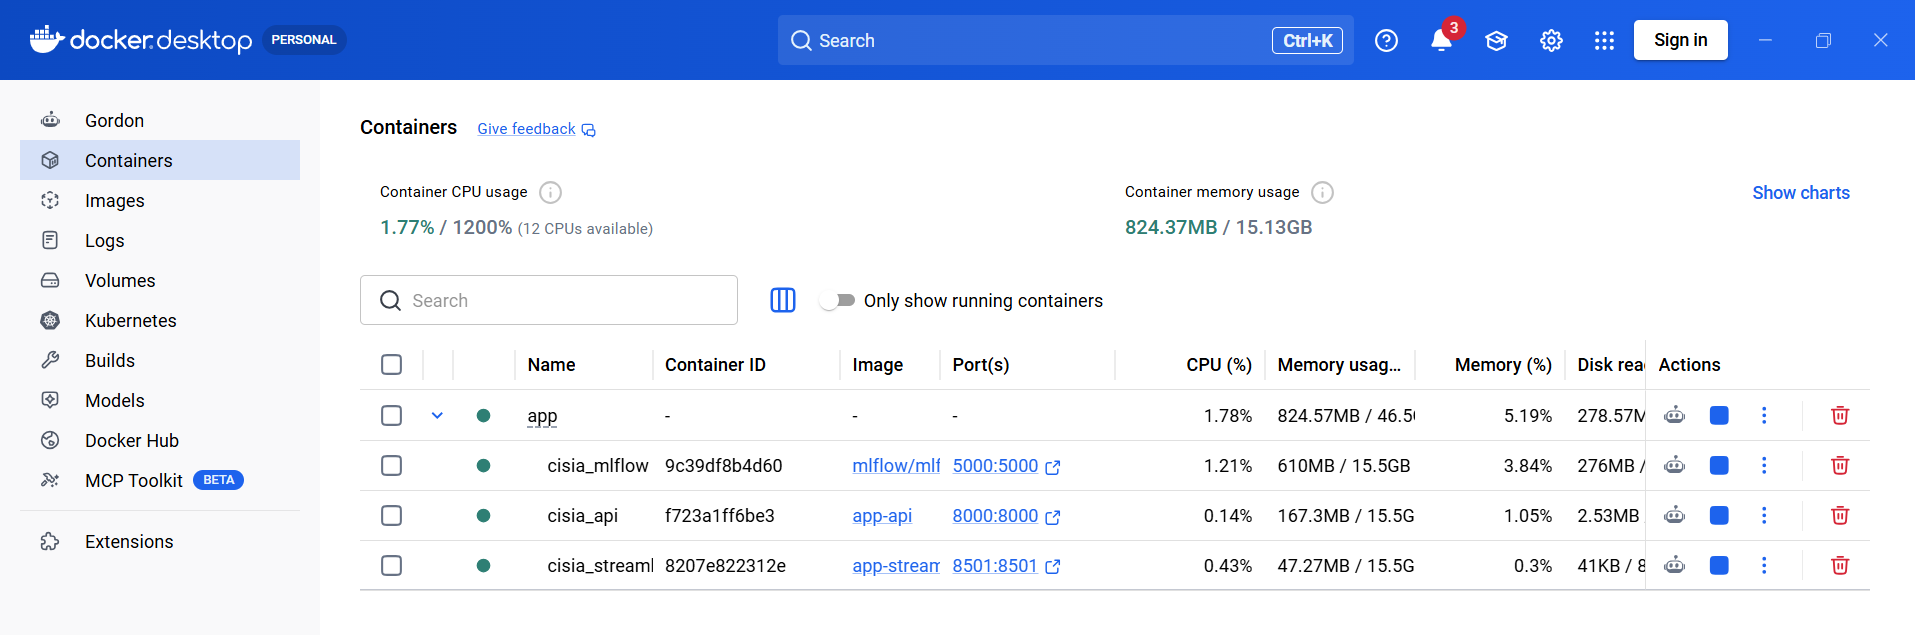


#### Github Actions

``` mermaid
flowchart TD

A[Push GitHub]

A --> B[GitHub Actions]

B --> C[Tests Pytest]
B --> D[Contrôle qualité]

C --> E[Build API Docker]
D --> E

E --> F[Build Streamlit Docker]

F --> G[GitHub Container Registry]

G --> H[docker compose pull]

H --> I[API FastAPI]

H --> J[UI Streamlit]

I --> K[MLflow]
```




### 🎯 Prochaines étapes

- Implémentation GitHub Action
- revue de code, nettoyage
- préparation présentation

## 📅 Journal de bord – Semaine 4 (28-29-30/09/2026)

### 🔧 Étapes / Actions réalisées

- 



### 📝 Observations / Difficultés

- 


### 🎯 Prochaines étapes

- 